# Extended Analysis of Human-Automated Score Agreement

This notebook is the general results-appendix notebook. It collects exploratory observations that are not the main table result but help explain where the automatic evaluator agrees with human raters, where it struggles, and what the survey design reveals.

The current appendix observations are:

1. **Some perceptual traits are easier to predict than others.**
2. **Human and automated scores have similar perceptual profiles.**
3. **Robot-experienced raters are more demanding.**
4. **Third-person view makes policy differences easier to see.**

A separate focused notebook, `appendix_robot_experience.ipynb`, expands point 3 in more detail.

## Setup

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

AXES = ["competence_control", "safety", "awareness", "positive_impression"]
AXIS_LABELS = {
    "competence_control": "Dexterity",
    "safety": "Safety",
    "awareness": "Social Awareness",
    "positive_impression": "Impression",
    "global": "Overall",
}
AXIS_COLORS = {
    "competence_control": "#2F6B9A",
    "safety": "#D66A35",
    "awareness": "#4E9A51",
    "positive_impression": "#8A5FBF",
    "global": "#4A4A4A",
}
SOURCE_COLORS = {
    "Human": "#1F4E79",
    "Auto": "#C84C31",
    "No daily contact": "#2F6B9A",
    "Daily robotics": "#D66A35",
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 350,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

def find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "paper" / "paper.tex").exists() and (path / "paper" / "data").exists():
            return path
    raise FileNotFoundError("Could not find repository root")

PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / "paper" / "data" / "human-survey" / "analysis_outputs"
OUTPUT_DIR = ANALYSIS_DIR / "appendix_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def project_path(path):
    return Path(path).relative_to(PROJECT_ROOT)


def save_figure(fig, stem):
    png = OUTPUT_DIR / f"{stem}.png"
    pdf = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    print(f"Saved {project_path(png)}")
    print(f"Saved {project_path(pdf)}")


def cosine_similarity(left, right):
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    return float(np.dot(left, right) / (np.linalg.norm(left) * np.linalg.norm(right)))


def centered_cosine_similarity(left, right):
    left = np.asarray(left, dtype=float) - np.mean(left)
    right = np.asarray(right, dtype=float) - np.mean(right)
    return float(np.dot(left, right) / (np.linalg.norm(left) * np.linalg.norm(right)))

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {project_path(OUTPUT_DIR)}")

FileNotFoundError: Could not find repository root

In [2]:
policy_table = pd.read_csv(ANALYSIS_DIR / "heldout_policy_metric_table.csv")
policy_spiderplot = pd.read_csv(ANALYSIS_DIR / "heldout_policy_spiderplot.csv")
survey_long = pd.read_csv(ANALYSIS_DIR / "survey_long.csv")
paired_results = pd.read_csv(ANALYSIS_DIR / "paired_results.csv")

display(
    pd.DataFrame(
        {
            "table": ["policy_table", "policy_spiderplot", "survey_long", "paired_results"],
            "rows": [len(policy_table), len(policy_spiderplot), len(survey_long), len(paired_results)],
        }
    )
)

,table,rows
0,policy_table,5
1,policy_spiderplot,16
2,survey_long,1120
3,paired_results,20


## 1. Some Perceptual Traits Are Easier to Predict Than Others

Dexterity is physically grounded in telemetry such as task success, completion time, path efficiency, and hesitation. Social Awareness is more contextual: the evaluator must infer whether the robot understood and responded appropriately to people. The residuals reflect this difference.

In [3]:
axis_errors = policy_table[policy_table["Metric"] != "AsimovBM"].copy()
axis_errors["axis_label"] = axis_errors["axis"].map(AXIS_LABELS)
axis_errors["Policy A abs error"] = (axis_errors["Policy A Auto"] - axis_errors["Policy A Human Mean"]).abs()
axis_errors["Policy B abs error"] = (axis_errors["Policy B Auto"] - axis_errors["Policy B Human Mean"]).abs()
axis_errors["Mean abs error"] = axis_errors[["Policy A abs error", "Policy B abs error"]].mean(axis=1)
axis_errors["axis_order"] = axis_errors["axis"].map({axis: index for index, axis in enumerate(AXES)})
axis_errors = axis_errors.sort_values("axis_order")

axis_predictability = axis_errors[
    [
        "axis",
        "axis_label",
        "Policy A abs error",
        "Policy B abs error",
        "Mean abs error",
        "Delta_%",
    ]
]
axis_predictability_path = OUTPUT_DIR / "appendix_axis_predictability.csv"
axis_predictability.to_csv(axis_predictability_path, index=False)

display(axis_predictability.round(1))
print(f"Saved {project_path(axis_predictability_path)}")

,axis,axis_label,Policy A abs error,Policy B abs error,Mean abs error,Delta_%
0,competence_control,Dexterity,2.0,2.4,2.2,95.6
1,safety,Safety,5.0,3.7,4.3,91.2
2,awareness,Social Awareness,3.9,7.4,5.6,88.6
3,positive_impression,Impression,4.9,4.3,4.6,90.8


Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_axis_predictability.csv


Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_axis_predictability.png
Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_axis_predictability.pdf


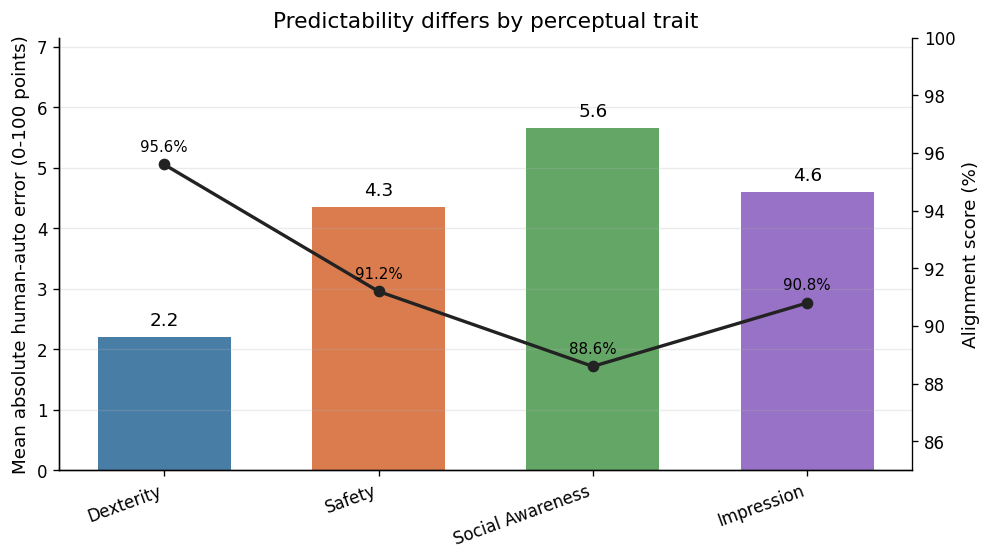

In [4]:
fig, ax_error = plt.subplots(figsize=(8.4, 4.8))
x = np.arange(len(axis_errors))
colors = [AXIS_COLORS[axis] for axis in axis_errors["axis"]]

bars = ax_error.bar(x, axis_errors["Mean abs error"], color=colors, alpha=0.88, width=0.62)
ax_error.set_title("Predictability differs by perceptual trait")
ax_error.set_ylabel("Mean absolute human-auto error (0-100 points)")
ax_error.set_xticks(x)
ax_error.set_xticklabels(axis_errors["axis_label"], rotation=20, ha="right")
ax_error.set_ylim(0, axis_errors["Mean abs error"].max() + 1.5)
ax_error.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, axis_errors["Mean abs error"]):
    ax_error.text(bar.get_x() + bar.get_width() / 2, value + 0.12, f"{value:.1f}", ha="center", va="bottom")

ax_alignment = ax_error.twinx()
ax_alignment.plot(x, axis_errors["Delta_%"], color="#222222", marker="o", linewidth=2.0)
ax_alignment.set_ylabel("Alignment score (%)")
ax_alignment.set_ylim(85, 100)
ax_alignment.spines["right"].set_visible(True)
for xi, value in zip(x, axis_errors["Delta_%"]):
    ax_alignment.text(xi, value + 0.35, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
save_figure(fig, "appendix_axis_predictability")
plt.show()

## 2. Human and Automated Scores Have Similar Perceptual Profiles

The spider plots are useful as profiles, not just point estimates. The automatic evaluator may be higher or lower in absolute level, but it often preserves the broad geometry of the human profile. Policy B is the useful exception: Social Awareness weakens the centered profile agreement and marks the main residual case.

In [5]:
profile_rows = []
policy_axis_table = axis_errors.set_index("axis").loc[AXES]

for policy in ["A", "B"]:
    human = policy_axis_table[f"Policy {policy} Human Mean"]
    auto = policy_axis_table[f"Policy {policy} Auto"]
    profile_rows.append(
        {
            "policy": f"Policy {policy}",
            "raw_profile_similarity": cosine_similarity(human, auto),
            "centered_profile_similarity": centered_cosine_similarity(human, auto),
            "mean_auto_minus_human": float((auto - human).mean()),
            "max_axis_abs_error": float((auto - human).abs().max()),
        }
    )

profile_similarity = pd.DataFrame(profile_rows)
profile_similarity_path = OUTPUT_DIR / "appendix_profile_similarity.csv"
profile_similarity.to_csv(profile_similarity_path, index=False)

display(profile_similarity.round(3))
print(f"Saved {project_path(profile_similarity_path)}")

,policy,raw_profile_similarity,centered_profile_similarity,mean_auto_minus_human,max_axis_abs_error
0,Policy A,0.999,0.991,3.95,5.0
1,Policy B,0.999,0.400,-4.45,7.4


Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_profile_similarity.csv


Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_profile_similarity_radar.png
Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_profile_similarity_radar.pdf


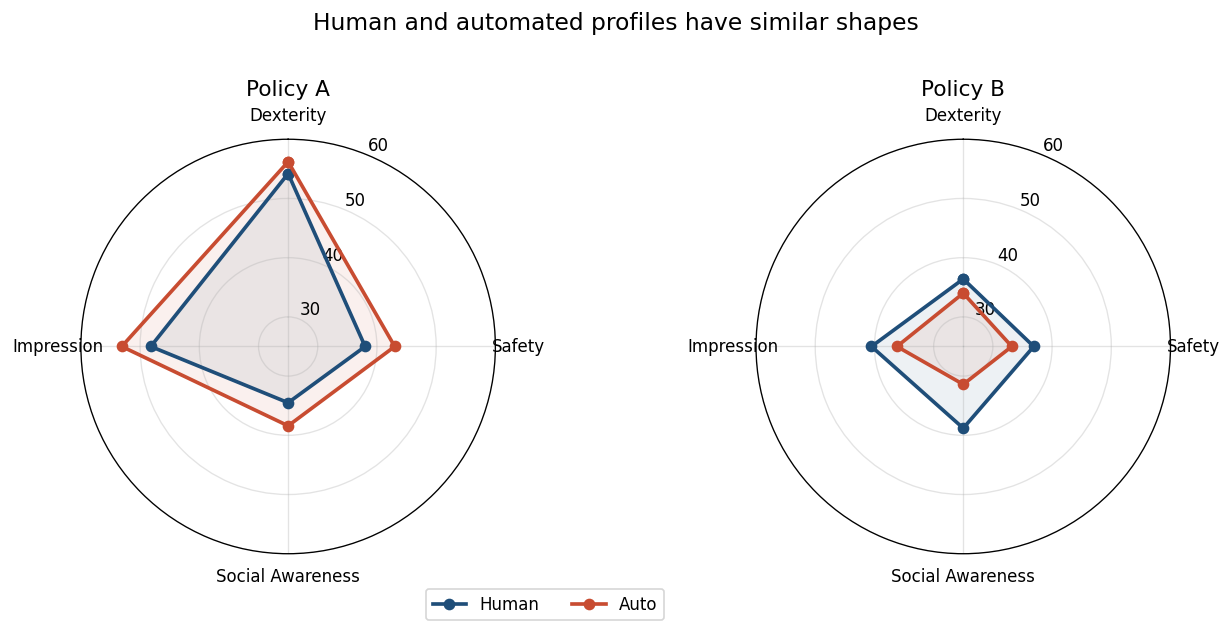

In [6]:
def close_loop(values):
    values = list(values)
    return values + values[:1]

angles = np.linspace(0, 2 * np.pi, len(AXES), endpoint=False)
closed_angles = close_loop(angles)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 5.1), subplot_kw={"projection": "polar"})

for ax, policy in zip(axes, ["A", "B"]):
    human = policy_axis_table[f"Policy {policy} Human Mean"].to_numpy(dtype=float)
    auto = policy_axis_table[f"Policy {policy} Auto"].to_numpy(dtype=float)

    for label, values, color in [
        ("Human", human, SOURCE_COLORS["Human"]),
        ("Auto", auto, SOURCE_COLORS["Auto"]),
    ]:
        ax.plot(closed_angles, close_loop(values), color=color, linewidth=2.2, marker="o", label=label)
        ax.fill(closed_angles, close_loop(values), color=color, alpha=0.08)

    ax.set_title(f"Policy {policy}", y=1.08)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels([AXIS_LABELS[axis] for axis in AXES])
    ax.set_ylim(25, 60)
    ax.set_yticks([30, 40, 50, 60])
    ax.set_yticklabels(["30", "40", "50", "60"])
    ax.grid(alpha=0.35)

axes[0].legend(loc="lower center", bbox_to_anchor=(1.12, -0.18), ncol=2, frameon=True)
fig.suptitle("Human and automated profiles have similar shapes", y=1.02, fontsize=14)
fig.tight_layout()
save_figure(fig, "appendix_profile_similarity_radar")
plt.show()

## 3. Robot-Experienced Raters Are More Demanding

Participants who report daily robotics contact tend to give lower scores overall. The likely interpretation is that experience raises expectations: experienced raters notice motion defects, awkward responses, or unsafe behavior more easily. The more detailed policy-by-policy version lives in `appendix_robot_experience.ipynb`.

In [7]:
survey_axes = survey_long[survey_long["axis"].isin(AXES)].copy()
survey_axes["score_0_100"] = (survey_axes["score"].astype(float) + 3.0) / 6.0 * 100.0
survey_axes["experience_group"] = survey_axes["robotics_familiarity"].map({False: "No daily contact", True: "Daily robotics"})

participant_axis = (
    survey_axes.groupby(["participant_id", "robotics_familiarity", "experience_group", "axis"], as_index=False)
    .agg(score_0_100=("score_0_100", "mean"))
)

experience_scores = (
    participant_axis.groupby(["experience_group", "axis"], as_index=False)
    .agg(mean_score=("score_0_100", "mean"), n_participants=("participant_id", "nunique"))
)
experience_table = (
    experience_scores.pivot(index="axis", columns="experience_group", values="mean_score")
    .loc[AXES]
    .reset_index()
)
experience_table["axis_label"] = experience_table["axis"].map(AXIS_LABELS)
experience_table["Daily minus no daily"] = experience_table["Daily robotics"] - experience_table["No daily contact"]

experience_similarity = pd.DataFrame(
    [
        {
            "raw_profile_similarity": cosine_similarity(experience_table["No daily contact"], experience_table["Daily robotics"]),
            "centered_profile_similarity": centered_cosine_similarity(experience_table["No daily contact"], experience_table["Daily robotics"]),
            "mean_daily_minus_no_daily": float(experience_table["Daily minus no daily"].mean()),
        }
    ]
)

experience_table_path = OUTPUT_DIR / "appendix_robot_experience_shift.csv"
experience_similarity_path = OUTPUT_DIR / "appendix_robot_experience_similarity.csv"
experience_table.to_csv(experience_table_path, index=False)
experience_similarity.to_csv(experience_similarity_path, index=False)

display(experience_table.round(1))
display(experience_similarity.round(3))
print(f"Saved {project_path(experience_table_path)}")
print(f"Saved {project_path(experience_similarity_path)}")

experience_group,axis,Daily robotics,No daily contact,axis_label,Daily minus no daily
0,competence_control,39.4,44.7,Dexterity,-5.3
1,safety,33.3,37.8,Safety,-4.5
2,awareness,29.2,36.3,Social Awareness,-7.1
3,positive_impression,36.9,45.2,Impression,-8.4


,raw_profile_similarity,centered_profile_similarity,mean_daily_minus_no_daily
0,0.999,0.924,-6.32


Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_robot_experience_shift.csv
Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_robot_experience_similarity.csv


Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_robot_experience_shift.png
Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_robot_experience_shift.pdf


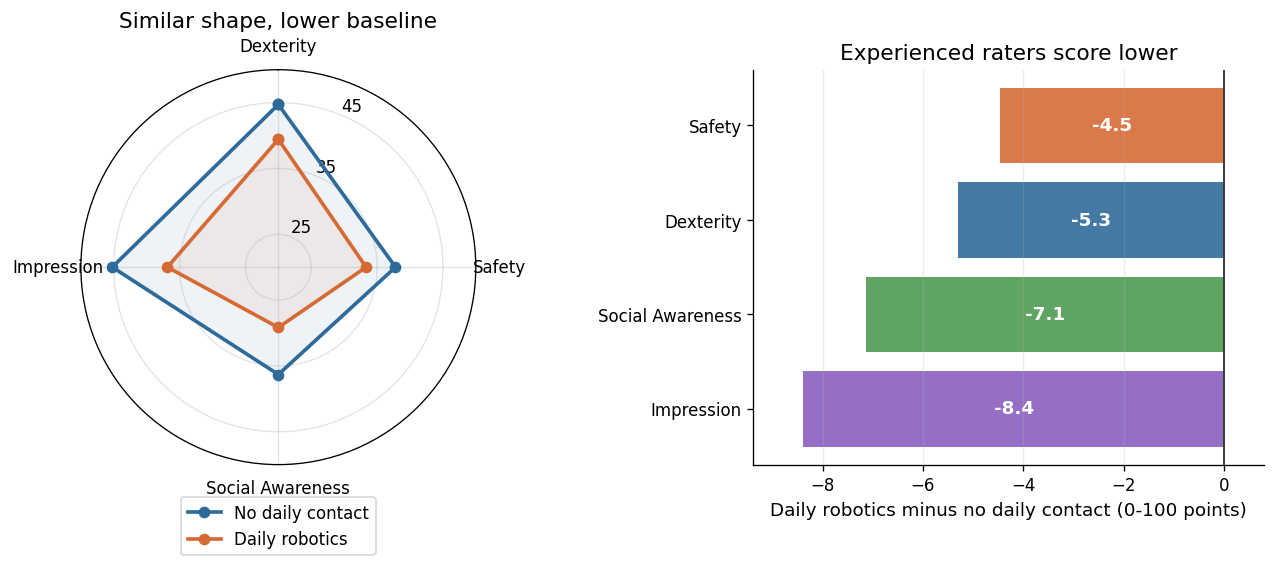

In [8]:
fig = plt.figure(figsize=(11.2, 5.0))
ax_radar = fig.add_subplot(1, 2, 1, projection="polar")
ax_shift = fig.add_subplot(1, 2, 2)

for label, color in [
    ("No daily contact", SOURCE_COLORS["No daily contact"]),
    ("Daily robotics", SOURCE_COLORS["Daily robotics"]),
]:
    values = experience_table[label].to_numpy(dtype=float)
    ax_radar.plot(closed_angles, close_loop(values), color=color, linewidth=2.2, marker="o", label=label)
    ax_radar.fill(closed_angles, close_loop(values), color=color, alpha=0.08)

ax_radar.set_title("Similar shape, lower baseline")
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels([AXIS_LABELS[axis] for axis in AXES])
ax_radar.set_ylim(20, 50)
ax_radar.set_yticks([25, 35, 45])
ax_radar.set_yticklabels(["25", "35", "45"])
ax_radar.grid(alpha=0.35)
ax_radar.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), frameon=True)

shift_rows = experience_table.sort_values("Daily minus no daily")
y = np.arange(len(shift_rows))
bars = ax_shift.barh(y, shift_rows["Daily minus no daily"], color=[AXIS_COLORS[a] for a in shift_rows["axis"]], alpha=0.9)
ax_shift.axvline(0, color="#333333", linewidth=1.1)
ax_shift.set_yticks(y)
ax_shift.set_yticklabels(shift_rows["axis_label"])
ax_shift.set_xlim(shift_rows["Daily minus no daily"].min() - 1.0, 0.8)
ax_shift.set_xlabel("Daily robotics minus no daily contact (0-100 points)")
ax_shift.set_title("Experienced raters score lower")
ax_shift.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, shift_rows["Daily minus no daily"]):
    ax_shift.text(value / 2, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", ha="center", va="center", color="white", fontweight="bold")

fig.tight_layout()
save_figure(fig, "appendix_robot_experience_shift")
plt.show()

## 4. Third-Person View Makes Policy Differences Easier to See

Policy differences are clearer from the external view, especially for Safety and Social Awareness. These axes depend on interaction geometry: bystander distance, approach direction, and whether the robot's behavior is appropriate around people.

In [9]:
pov_rows = paired_results[
    paired_results["comparison"].isin(["A vs B - first-person POV", "A vs B - third-person POV"])
    & paired_results["axis"].isin(AXES + ["global"])
].copy()
pov_rows["view"] = np.where(pov_rows["comparison"].str.contains("first-person"), "First person", "Third person")
pov_rows["axis_label"] = pov_rows["axis"].map(AXIS_LABELS)
pov_rows["axis_order"] = pov_rows["axis"].map({axis: index for index, axis in enumerate(AXES + ["global"])})

pov_delta = (
    pov_rows.pivot(index=["axis", "axis_label", "axis_order"], columns="view", values="mean_delta")
    .reset_index()
    .sort_values("axis_order")
)
pov_delta["Third minus first"] = pov_delta["Third person"] - pov_delta["First person"]

pov_advantage = (
    pov_rows.pivot(index=["axis", "axis_label", "axis_order"], columns="view", values="relative_perceived_advantage")
    .reset_index()
    .sort_values("axis_order")
)
pov_advantage["Third minus first"] = pov_advantage["Third person"] - pov_advantage["First person"]

pov_delta_path = OUTPUT_DIR / "appendix_pov_policy_separation.csv"
pov_advantage_path = OUTPUT_DIR / "appendix_pov_relative_advantage.csv"
pov_delta.to_csv(pov_delta_path, index=False)
pov_advantage.to_csv(pov_advantage_path, index=False)

display(pov_delta.drop(columns="axis_order").round(3))
display(pov_advantage.drop(columns="axis_order").round(3))
print(f"Saved {project_path(pov_delta_path)}")
print(f"Saved {project_path(pov_advantage_path)}")

view,axis,axis_label,First person,Third person,Third minus first
1,competence_control,Dexterity,1.071,1.400,0.329
4,safety,Safety,0.043,0.543,0.500
0,awareness,Social Awareness,0.000,0.343,0.343
3,positive_impression,Impression,0.671,0.729,0.057
2,global,Overall,0.453,0.750,0.297


view,axis,axis_label,First person,Third person,Third minus first
1,competence_control,Dexterity,0.736,0.821,0.086
4,safety,Safety,0.521,0.643,0.121
0,awareness,Social Awareness,0.529,0.643,0.114
3,positive_impression,Impression,0.657,0.729,0.071
2,global,Overall,0.652,0.746,0.094


Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_pov_policy_separation.csv
Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_pov_relative_advantage.csv


Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_pov_policy_separation.png
Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_pov_policy_separation.pdf


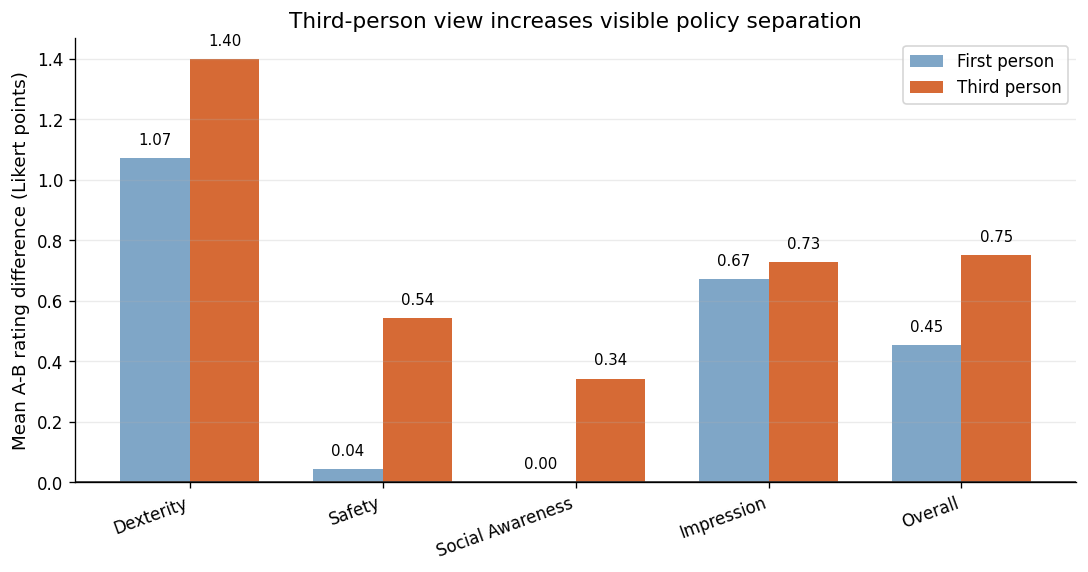

In [10]:
fig, ax = plt.subplots(figsize=(9.2, 4.9))
plot_delta = pov_delta.copy()
x = np.arange(len(plot_delta))
width = 0.36

first_bars = ax.bar(x - width / 2, plot_delta["First person"], width, label="First person", color="#7FA6C7")
third_bars = ax.bar(x + width / 2, plot_delta["Third person"], width, label="Third person", color="#D66A35")
ax.axhline(0, color="#333333", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(plot_delta["axis_label"], rotation=20, ha="right")
ax.set_ylabel("Mean A-B rating difference (Likert points)")
ax.set_title("Third-person view increases visible policy separation")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.25)

for bars in [first_bars, third_bars]:
    for bar in bars:
        value = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.035, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
save_figure(fig, "appendix_pov_policy_separation")
plt.show()

## Paper-Ready Summary

In [11]:
dexterity_error = float(axis_predictability.loc[axis_predictability["axis"] == "competence_control", "Mean abs error"].iloc[0])
social_error = float(axis_predictability.loc[axis_predictability["axis"] == "awareness", "Mean abs error"].iloc[0])
dexterity_alignment = float(axis_predictability.loc[axis_predictability["axis"] == "competence_control", "Delta_%"].iloc[0])
social_alignment = float(axis_predictability.loc[axis_predictability["axis"] == "awareness", "Delta_%"].iloc[0])
policy_a_raw = float(profile_similarity.loc[profile_similarity["policy"] == "Policy A", "raw_profile_similarity"].iloc[0])
policy_b_raw = float(profile_similarity.loc[profile_similarity["policy"] == "Policy B", "raw_profile_similarity"].iloc[0])
policy_b_centered = float(profile_similarity.loc[profile_similarity["policy"] == "Policy B", "centered_profile_similarity"].iloc[0])
experience_shift = float(experience_similarity["mean_daily_minus_no_daily"].iloc[0])
experience_centered = float(experience_similarity["centered_profile_similarity"].iloc[0])
global_first = float(pov_delta.loc[pov_delta["axis"] == "global", "First person"].iloc[0])
global_third = float(pov_delta.loc[pov_delta["axis"] == "global", "Third person"].iloc[0])
safety_gain = float(pov_delta.loc[pov_delta["axis"] == "safety", "Third minus first"].iloc[0])
awareness_gain = float(pov_delta.loc[pov_delta["axis"] == "awareness", "Third minus first"].iloc[0])

summary = f"""
### Extended Analysis of Human-Automated Score Agreement

**Some perceptual traits are easier to predict than others.** Dexterity has the smallest mean absolute human-auto error ({dexterity_error:.1f} points) and the highest alignment score ({dexterity_alignment:.1f}%). Social Awareness has the largest mean absolute error ({social_error:.1f} points) and the lowest alignment score ({social_alignment:.1f}%).

**Human and automated scores have similar perceptual profiles.** The raw profile similarity between human and automated scores is very high for both Policy A ({policy_a_raw:.3f}) and Policy B ({policy_b_raw:.3f}). Policy B has a lower centered profile similarity ({policy_b_centered:.3f}), identifying Social Awareness as the main residual exception.

**Robot-experienced raters are more demanding.** Participants with daily robotics contact score the videos lower by {abs(experience_shift):.1f} points on average. The centered profile similarity remains high ({experience_centered:.3f}), suggesting that experience mostly shifts the rating baseline downward.

**Third-person view makes policy differences easier to see.** The overall A-B rating gap increases from {global_first:.2f} Likert points in first-person view to {global_third:.2f} in third-person view. The largest viewpoint gains are on Safety (+{safety_gain:.2f}) and Social Awareness (+{awareness_gain:.2f}).
""".strip()

summary_path = OUTPUT_DIR / "appendix_paper_ready_summary.md"
summary_path.write_text(summary + "\n")
display(Markdown(summary))
print(f"Saved {project_path(summary_path)}")

### Extended Analysis of Human-Automated Score Agreement

**Some perceptual traits are easier to predict than others.** Dexterity has the smallest mean absolute human-auto error (2.2 points) and the highest alignment score (95.6%). Social Awareness has the largest mean absolute error (5.6 points) and the lowest alignment score (88.6%).

**Human and automated scores have similar perceptual profiles.** The raw profile similarity between human and automated scores is very high for both Policy A (0.999) and Policy B (0.999). Policy B has a lower centered profile similarity (0.400), identifying Social Awareness as the main residual exception.

**Robot-experienced raters are more demanding.** Participants with daily robotics contact score the videos lower by 6.3 points on average. The centered profile similarity remains high (0.924), suggesting that experience mostly shifts the rating baseline downward.

**Third-person view makes policy differences easier to see.** The overall A-B rating gap increases from 0.45 Likert points in first-person view to 0.75 in third-person view. The largest viewpoint gains are on Safety (+0.50) and Social Awareness (+0.34).

Saved paper/data/human-survey/analysis_outputs/appendix_results/appendix_paper_ready_summary.md


In [12]:
outputs = sorted(path for path in OUTPUT_DIR.iterdir() if path.is_file())
display(pd.DataFrame({"output_file": [str(project_path(path)) for path in outputs]}))

,output_file
0,paper/data/human-survey/analysis_outputs/appen...
1,paper/data/human-survey/analysis_outputs/appen...
2,paper/data/human-survey/analysis_outputs/appen...
3,paper/data/human-survey/analysis_outputs/appen...
4,paper/data/human-survey/analysis_outputs/appen...
5,paper/data/human-survey/analysis_outputs/appen...
6,paper/data/human-survey/analysis_outputs/appen...
7,paper/data/human-survey/analysis_outputs/appen...
8,paper/data/human-survey/analysis_outputs/appen...
9,paper/data/human-survey/analysis_outputs/appen...
